<a href="https://colab.research.google.com/github/wilszon/Clase-Inteligencia-Artificial/blob/main/EjemploSVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("mathchi/diabetes-data-set")
print("Path to dataset files:", path)

df = pd.read_csv(path + "/diabetes.csv")

Path to dataset files: /root/.cache/kagglehub/datasets/mathchi/diabetes-data-set/versions/1


In [7]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


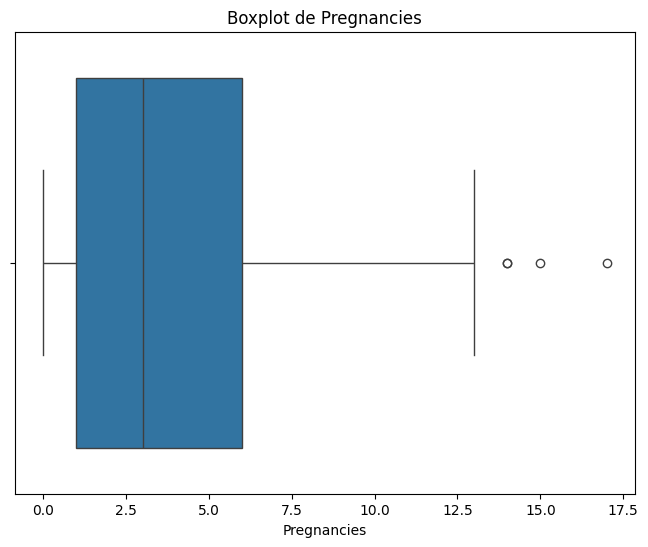

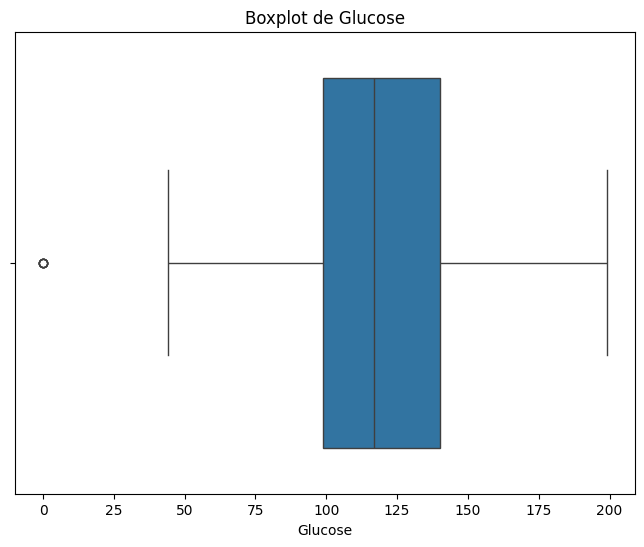

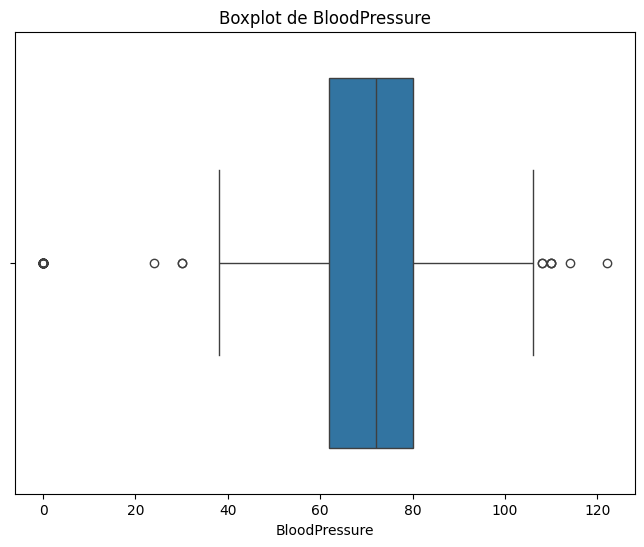

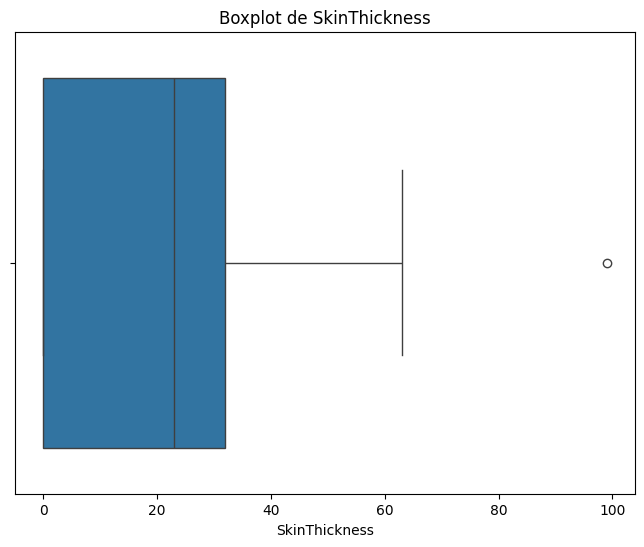

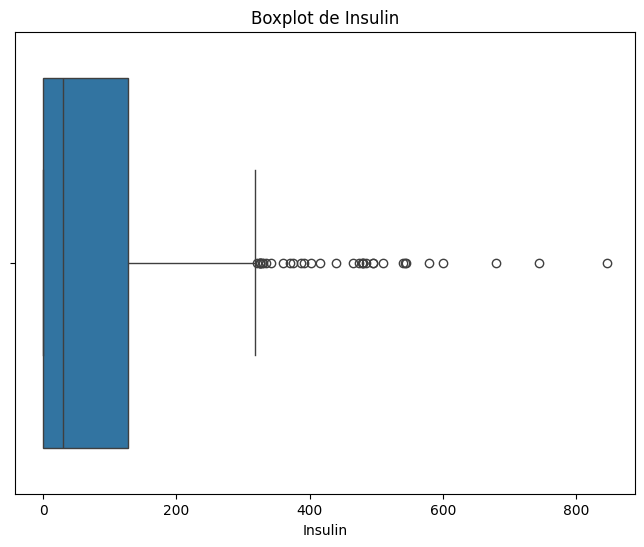

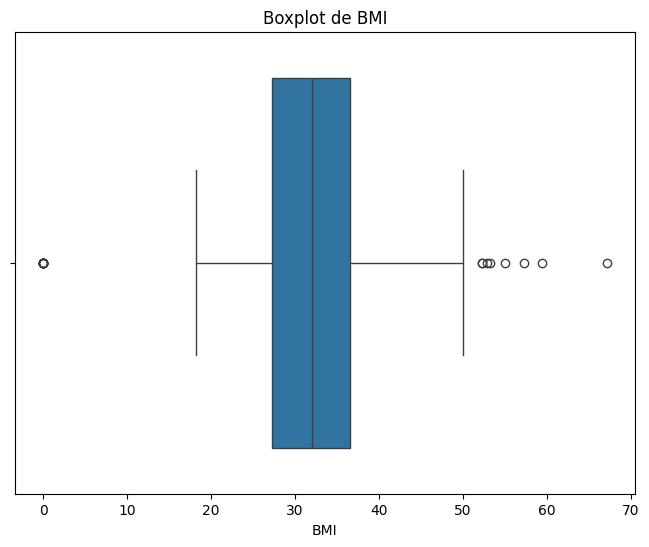

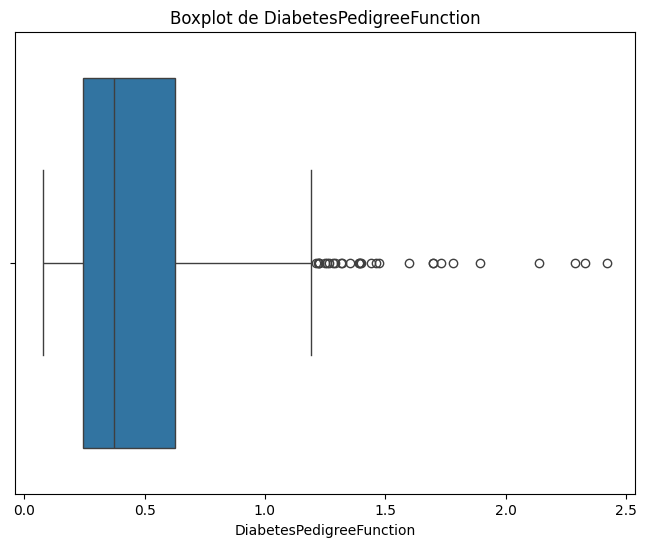

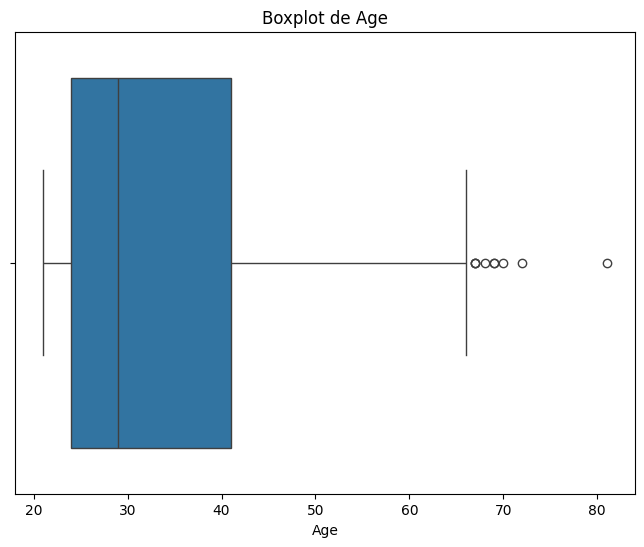

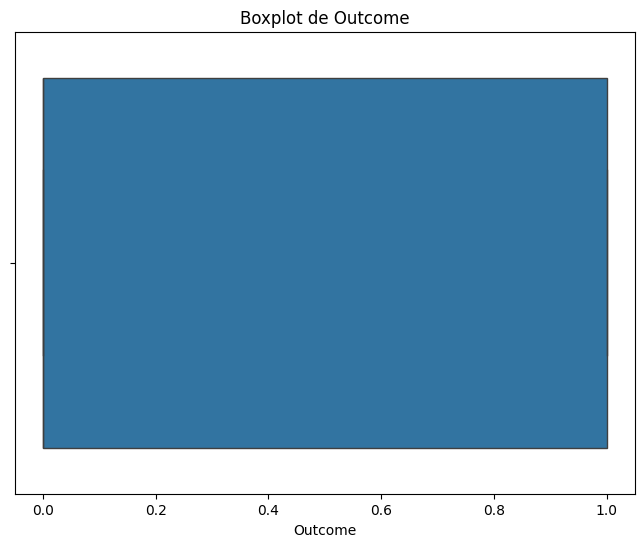

In [9]:
# prompt: #vamos a graficar la caja de bigotes de cada una de los features

import matplotlib.pyplot as plt
import seaborn as sns

# Vamos a graficar la caja de bigotes de cada una de los features
for column in df.columns:
  plt.figure(figsize=(8, 6))
  sns.boxplot(x=df[column])
  plt.title(f'Boxplot de {column}')
  plt.show()


In [10]:
# prompt: Separame los datos de entrenamiento y de prueba y los datos etiquetados son Outcome

from sklearn.model_selection import train_test_split

# Separamos los datos en características (X) y etiquetas (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Dividimos los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Imprimimos las dimensiones de los conjuntos de entrenamiento y prueba
print("Dimensiones del conjunto de entrenamiento:", X_train.shape, y_train.shape)
print("Dimensiones del conjunto de prueba:", X_test.shape, y_test.shape)


Dimensiones del conjunto de entrenamiento: (576, 8) (576,)
Dimensiones del conjunto de prueba: (192, 8) (192,)


In [11]:
stratify = df['Outcome'].value_counts()
print(stratify)

Outcome
0    500
1    268
Name: count, dtype: int64


In [13]:
#Normalizamos los features de entrenamiento y los datos de prueba usando MinMax
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)




In [32]:
#Entrenar en SVC los features y la etiqueta

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Entrenar el modelo SVC
svc = SVC(C=.5)
svc.fit(X_train, y_train)

SVC(C=0.5)

In [33]:
#El accuracy del modelo SVC

y_pred = svc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy del modelo SVC:", accuracy)

Accuracy del modelo SVC: 0.765625


In [34]:
# prompt: Realizar inferencias del modelo de SVC utilizando Gridsearch usando C de 0.5 a 5 con pasos de 0.1, y kernel{‘linear’, ‘poly’, ‘rbf’)

from sklearn.model_selection import GridSearchCV

# Definir los parámetros para la búsqueda en cuadrícula
param_grid = {'C': [i/10 for i in range(5, 51)], 'kernel': ['linear', 'poly', 'rbf']}

# Crear un modelo SVC
svc = SVC()

# Crear un objeto GridSearchCV
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5)

# Ajustar el modelo a los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Imprimir los mejores parámetros y la puntuación
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor puntuación:", grid_search.best_score_)

# Realizar predicciones con el mejor modelo
y_pred = grid_search.predict(X_test)

# Calcular la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del modelo:", accuracy)


Mejores parámetros: {'C': 1.6, 'kernel': 'linear'}
Mejor puntuación: 0.7725337331334334
Precisión del modelo: 0.734375
